In [2]:
import numpy as np
import matplotlib.pyplot as plt
from deepOnet_definitions import *
from FFEM_building_blocks import Mesh


Mass matrix initialization completed
Stiffness matrix initialization completed


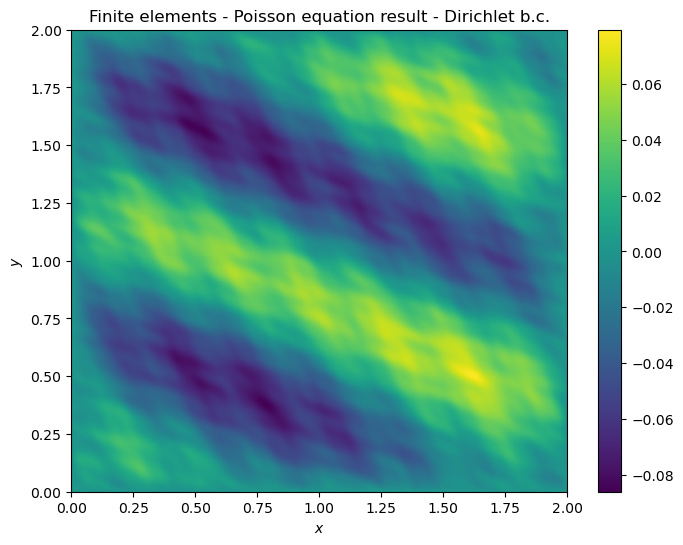

In [ ]:
# test for the automatic generation of source functions and the Poisson solution algorithm


def generate_source_function(num_modes:int=20, max_freq:int=100, max_amplitude = 10.):
    """
    Uses a random truncated Fourier series with random amplitudes
    """
    # first pick some frequencies
    kx = np.random.randint(1, max_freq + 1, size=num_modes)
    ky = np.random.randint(1, max_freq + 1, size=num_modes)

    # now draw the corresponding amplitudes and phases
    amplitudes = np.random.uniform(-max_amplitude, max_amplitude, size=num_modes)
    phases = np.random.uniform(0, 2 * np.pi, size=num_modes)

    def source_function(x, y):
        result = 0
        for i in range(num_modes):
            result += amplitudes[i] * np.cos(kx[i] * x + ky[i] * y + phases[i])
        return result

    return source_function
    


x = np.linspace(0, 2, 200)
y = np.linspace(0, 2, 200)
mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()
# coordinates of mesh points 
X, Y = np.meshgrid(x, y, indexing="ij")
coords = np.stack([X.ravel(), Y.ravel()], axis=-1)
diri = lambda x, y: 0

func = generate_source_function()
res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)
plt.figure(figsize=(8, 6))
plt.imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('Finite elements - Poisson equation result - Dirichlet b.c.')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()
